# Sequence Analysis


In [14]:
import os
from pathlib import Path
from pynwb import NWBHDF5IO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up paths
data_root = Path("E:/SBCAT/data/000469")


## All Functions

All functions are defined below, organized by category:
- **Trial Selection**: Select trials by load, correctness, probe in/out, or indices
- **File Listing**: List and select NWB files
- **Data Extraction**: Extract spike data and trial information from NWB files
- **DataFrame Creation**: Convert extraction results to DataFrames
- **Spike Segmentation**: Segment spikes by trials, aligned to specific events
- **Workflow**: Process single or multiple sessions

In [15]:
def select_trials_by_load(trials_df, load_values):
    """
    Select trials by memory load values (session-level).
    Args:
        trials_df: DataFrame with trial info
        load_values: int or list of int (e.g., 1, or [1,3])
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of row indices selected
    """
    if 'loads' not in trials_df.columns:
        raise ValueError("trials_df must have a 'loads' column")
    if not isinstance(load_values, (list, tuple, np.ndarray)):
        load_values = [load_values]
    mask = trials_df['loads'].isin(load_values)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices

def select_trials_by_correctness(trials_df, correct_only=True):
    """
    Select trials by correctness.
    Args:
        trials_df: DataFrame
        correct_only: bool
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of selected
    """
    if 'response_accuracy' not in trials_df.columns:
        raise ValueError("trials_df must have a 'response_accuracy' column")
    mask = (trials_df['response_accuracy'] == 1) if correct_only else (trials_df['response_accuracy'] != 1)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices
def list_available_files(data_dir, session_filter=None):
    """List all available NWB files with indices for selection.
    Args:
        data_dir: path object or string to root dir
        session_filter: 'ses-1', 'ses-2', or None
    Returns:
        files: list of Path
    """
    files = sorted(data_dir.rglob("*.nwb"))
    if session_filter in ["ses-1", "ses-2"]:
        files = [f for f in files if session_filter in f.name]
        print(f"Found {len(files)} NWB files (session filter = {session_filter}):\n")
    else:
        print(f"Found {len(files)} NWB files:\n")
    for i, f in enumerate(files):
        rel_path = f.relative_to(data_dir)
        print(f"{i:3d}. {rel_path}")
    return files

def extract_spike_data(filepath, include_waveforms=False, quality_filters=None, include_trials=True):
    """
    Extract spike data from an NWB file.
    Args:
        filepath: Path object or string for file.
        include_waveforms: bool
        quality_filters: dict
        include_trials: bool
    Returns:
        dict with
          - 'filepath'
          - 'subject_id'
          - 'session_id'
          - 'units': list of dict
          - 'trials': DataFrame or None
    """
    filepath = Path(filepath)
    # Subject/session from file name
    parts = filepath.stem.split('_')
    subject_id = None
    session_id = None
    for part in parts:
        if part.startswith('sub-'):
            subject_id = int(part.split('-')[1])
        elif part.startswith('ses-'):
            session_id = int(part.split('-')[1])
    result = {
        'filepath': str(filepath),
        'subject_id': subject_id,
        'session_id': session_id,
        'units': []
    }
    try:
        with NWBHDF5IO(str(filepath), mode="r", load_namespaces=True) as io:
            nwbf = io.read()
            # trials
            if include_trials and nwbf.trials is not None:
                try:
                    trials_df = nwbf.trials.to_dataframe()
                    result['trials'] = trials_df
                except Exception as e:
                    print(f"Warning: Could not extract trials from {filepath.name}: {e}")
                    result['trials'] = None
            else:
                result['trials'] = None
            if nwbf.units is None:
                print(f"Warning: No units found in {filepath.name}")
                return result
            units_df = nwbf.units.to_dataframe()
            electrodes_df = nwbf.electrodes.to_dataframe() if nwbf.electrodes is not None else None
            for unit_idx in units_df.index:
                unit_data = {
                    'unit_id': int(unit_idx),
                    'spike_times': None,
                    'electrode_idx': None,
                    'cluster_id': None,
                    'mean_snr': None,
                    'peak_snr': None,
                    'isolation_distance': None,
                    'mean_proj_dist': None,
                    'n_spikes': 0,
                    'brain_region': None
                }
                # spike times
                try:
                    spike_times = np.array(nwbf.units['spike_times'][unit_idx][:])
                    unit_data['spike_times'] = spike_times
                    unit_data['n_spikes'] = len(spike_times)
                except Exception as e:
                    print(f"Warning: Could not extract spike times for unit {unit_idx}: {e}")
                    continue
                # electrode info
                if 'electrodes' in units_df.columns:
                    try:
                        electrode_info = units_df.loc[unit_idx, 'electrodes']
                        if hasattr(electrode_info, 'index'):
                            unit_data['electrode_idx'] = int(electrode_info.index[0]) if len(electrode_info.index) > 0 else None
                        else:
                            unit_data['electrode_idx'] = int(electrode_info) if pd.notna(electrode_info) else None
                        if unit_data['electrode_idx'] is not None and electrodes_df is not None:
                            if 'location' in electrodes_df.columns:
                                unit_data['brain_region'] = electrodes_df.loc[unit_data['electrode_idx'], 'location']
                    except Exception:
                        pass
                # quality metrics
                if 'clusterID_orig' in units_df.columns:
                    unit_data['cluster_id'] = units_df.loc[unit_idx, 'clusterID_orig']
                if 'waveforms_mean_snr' in units_df.columns:
                    unit_data['mean_snr'] = units_df.loc[unit_idx, 'waveforms_mean_snr']
                if 'waveforms_peak_snr' in units_df.columns:
                    unit_data['peak_snr'] = units_df.loc[unit_idx, 'waveforms_peak_snr']
                if 'waveforms_isolation_distance' in units_df.columns:
                    unit_data['isolation_distance'] = units_df.loc[unit_idx, 'waveforms_isolation_distance']
                if 'waveforms_mean_proj_dist' in units_df.columns:
                    unit_data['mean_proj_dist'] = units_df.loc[unit_idx, 'waveforms_mean_proj_dist']
                # filter
                if quality_filters is not None:
                    skip_unit = False
                    if 'min_snr' in quality_filters and unit_data['mean_snr'] is not None:
                        if unit_data['mean_snr'] < quality_filters['min_snr']:
                            skip_unit = True
                    if 'min_isolation_distance' in quality_filters and unit_data['isolation_distance'] is not None:
                        if unit_data['isolation_distance'] < quality_filters['min_isolation_distance']:
                            skip_unit = True
                    if 'min_n_spikes' in quality_filters:
                        if unit_data['n_spikes'] < quality_filters['min_n_spikes']:
                            skip_unit = True
                    if skip_unit:
                        continue
                # waveforms
                if include_waveforms and 'waveforms' in units_df.columns:
                    try:
                        waveforms = np.array(nwbf.units['waveforms'][unit_idx][:])
                        unit_data['waveforms'] = waveforms
                    except Exception:
                        pass
                result['units'].append(unit_data)
    except Exception as e:
        print(f"Error processing {filepath.name}: {e}")
        import traceback
        traceback.print_exc()
    return result
def segment_spikes_by_trials(spike_times, trials_df, align_to='start_time', time_window=None):
    """
    Segment spikes by trials, aligned to align_to column.
    Args:
        spike_times: 1D array
        trials_df: DataFrame
        align_to: str, column to align to
        time_window: (start_offset, end_offset) or None
    Returns:
        list of arrays, one per trial (aligned)
    """
    segmented_spikes = []
    for trial_idx, trial in trials_df.iterrows():
        if align_to in trial and pd.notna(trial[align_to]) and trial[align_to] > 0:
            alignment_point = trial[align_to]
        elif 'start_time' in trial:
            alignment_point = trial['start_time']
        else:
            segmented_spikes.append(np.array([]))
            continue
        if time_window is not None:
            window_start = alignment_point + time_window[0]
            window_end = alignment_point + time_window[1]
        else:
            window_start = trial.get('start_time', alignment_point)
            window_end = trial.get('stop_time', alignment_point + 10.0)
        mask = (spike_times >= window_start) & (spike_times < window_end)
        trial_spikes = spike_times[mask]
        aligned_spikes = trial_spikes - alignment_point
        segmented_spikes.append(aligned_spikes)
    return segmented_spikes

def segment_spikes_by_selected_trials(spike_times, trials_df, selected_trial_indices=None,
                                      align_to='start_time', time_window=None):
    """
    Segment spikes for selected trials, as above but possibly a subset.
    Args:
        spike_times: 1D array
        trials_df: DataFrame
        selected_trial_indices: indices or None
        align_to: str
        time_window: tuple or None
    Returns:
        list of arrays, one per selected trial (aligned)
    """
    if selected_trial_indices is not None:
        selected_trials_df = trials_df.iloc[selected_trial_indices].copy()
        selected_trials_df = selected_trials_df.reset_index(drop=True)
    else:
        selected_trials_df = trials_df
    return segment_spikes_by_trials(
        spike_times,
        selected_trials_df,
        align_to=align_to,
        time_window=time_window
    )
def create_unit_metadata_df(extraction_result):
    """
    DataFrame of all metadata for each unit (no spikes).
    Args:
        extraction_result: result from extract_spike_data
    Returns:
        DataFrame
    """
    unit_rows = []
    for unit in extraction_result['units']:
        row = {
            'subject_id': extraction_result['subject_id'],
            'session_id': extraction_result['session_id'],
            'filepath': extraction_result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist']
        }
        unit_rows.append(row)
    return pd.DataFrame(unit_rows)
def collapse_hemispheres(compiled_df, inplace=False):
    """
    Collapse left/right hemispheres for brain_region. Adds 'brain_region_collapsed' column.
    Args:
        compiled_df: DataFrame
        inplace: bool
    Returns:
        DataFrame with 'brain_region_collapsed'
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    df = compiled_df if inplace else compiled_df.copy()
    def collapse_region(region):
        if pd.isna(region) or region is None:
            return region
        region_str = str(region).strip()
        if region_str.lower().endswith('_left'):
            return region_str[:-5]
        elif region_str.lower().endswith('_right'):
            return region_str[:-6]
        else:
            return region_str
    df['brain_region_collapsed'] = df['brain_region'].apply(collapse_region)
    return df

def list_available_brain_regions(compiled_df, show_collapsed=True):
    """
    Print all unique regions (and collapsed regions, if requested).
    Args:
        compiled_df: DataFrame with 'brain_region'
        show_collapsed: bool
    Returns:
        (original_regions, collapsed_regions)
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    original_regions = compiled_df['brain_region'].dropna().unique()
    original_regions = sorted([str(r) for r in original_regions if r is not None])
    print("=== Available Brain Regions ===")
    print(f"\nOriginal regions ({len(original_regions)}):")
    for i, region in enumerate(original_regions, 1):
        count = len(compiled_df[compiled_df['brain_region'] == region])
        print(f"  {i:2d}. {region:30s} ({count} units)")
    if show_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            df_temp = collapse_hemispheres(compiled_df.copy())
        else:
            df_temp = compiled_df
        collapsed_regions = df_temp['brain_region_collapsed'].dropna().unique()
        collapsed_regions = sorted([str(r) for r in collapsed_regions if r is not None])
        print(f"\nCollapsed regions ({len(collapsed_regions)}):")
        for i, region in enumerate(collapsed_regions, 1):
            count = len(df_temp[df_temp['brain_region_collapsed'] == region])
            print(f"  {i:2d}. {region:30s} ({count} units)")
        return original_regions, collapsed_regions
    return original_regions, None

def select_units_by_brain_region(compiled_df, brain_regions, match_type='exact', use_collapsed=True):
    """
    Select units by brain region.
    Args:
        compiled_df: DataFrame
        brain_regions: str or list
        match_type: 'exact' or 'contains'
        use_collapsed: bool
    Returns:
        filtered_df: DataFrame
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    if use_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            compiled_df = collapse_hemispheres(compiled_df.copy())
        region_col = 'brain_region_collapsed'
    else:
        region_col = 'brain_region'
    if isinstance(brain_regions, str):
        brain_regions = [brain_regions]
    if match_type == 'exact':
        mask = compiled_df[region_col].isin(brain_regions)
    elif match_type == 'contains':
        mask = compiled_df[region_col].astype(str).str.contains(
            '|'.join(brain_regions), case=False, na=False, regex=True
        )
    else:
        raise ValueError(f"Unknown match_type: {match_type}. Use 'exact' or 'contains'")
    filtered_df = compiled_df[mask].copy()
    return filtered_df

def assign_trial_conditions_per_unit(trials_df, encoding_epoch=1, 
                                     selected_trial_indices=None, n_conditions=5):
    """
    Assign each trial a 0-based condition index based on stimulus number (1..n_conditions).
    Ensures a fixed condition axis across sessions; missing/invalid IDs map to 0.
    Args:
        trials_df: DataFrame
        encoding_epoch: 1 or 3
        selected_trial_indices: indices or None
        n_conditions: total number of stimulus conditions (default 5)
    Returns:
        trial_conditions: np.array of length n_trials (0-based condition index)
    """
    pic_col = 'loadsEnc1_PicIDs' if encoding_epoch == 1 else 'loadsEnc3_PicIDs'
    trials_subset = trials_df.iloc[selected_trial_indices] if selected_trial_indices is not None else trials_df

    def map_pic_id(pic_id):
        if pd.isna(pic_id) or pic_id is None:
            return 0
        try:
            pid = int(pic_id)
        except Exception:
            return 0
        if pid <= 0:
            return 0
        idx = pid - 1
        # Clamp to configured condition count to avoid out-of-range indices
        return min(idx, n_conditions - 1)

    trial_conditions = np.array([map_pic_id(pic_id) for pic_id in trials_subset[pic_col]])
    return trial_conditions

def compute_mean_rate_hz(segmented_spikes, time_window):
    """
    Compute mean firing rate (Hz) across selected trials for one unit.
    Args:
        segmented_spikes: list of arrays, one per selected trial
        time_window: tuple (start, end) defining alignment window
    Returns:
        mean_rate_hz: float (spikes/sec), or np.nan if not computable
    """
    if time_window is None:
        return np.nan
    window_start, window_end = time_window
    window_duration = window_end - window_start
    if window_duration <= 0:
        return np.nan
    total_spikes = sum(len(trial) for trial in segmented_spikes)
    total_time = len(segmented_spikes) * window_duration
    if total_time <= 0:
        return np.nan
    return total_spikes / total_time


def build_firing_rate_matrix_per_unit(segmented_spikes, trial_conditions, n_conditions,
                                      bin_size=0.02, time_range=None):
    """
    Build a unit's per-condition × timebin matrix (1 vector) using raw binned rates.
    Args:
        segmented_spikes: list of arrays, one per trial
        trial_conditions: np.array, int index per trial
        n_conditions: int
        bin_size: float, seconds
        time_range: (start, end) or None
    Returns:
        row_vector: 1D np.array (n_conditions * n_bins)
        bin_edges: np.array
    """
    if time_range is None:
        all_times = []
        for trial_spikes in segmented_spikes:
            if len(trial_spikes) > 0:
                all_times.extend(trial_spikes)
        if len(all_times) == 0:
            time_range = (0, 1)
        else:
            time_range = (min(all_times), max(all_times))
    start_time, end_time = time_range
    n_bins = int(np.ceil((end_time - start_time) / bin_size))
    bin_edges = np.linspace(start_time, end_time, n_bins + 1)
    row_vector = np.zeros(n_conditions * n_bins)
    for cond_idx in range(n_conditions):
        cond_mask = trial_conditions == cond_idx
        cond_trial_indices = np.where(cond_mask)[0]
        if len(cond_trial_indices) == 0:
            continue
        trial_binned = []
        for trial_idx in cond_trial_indices:
            trial_spikes = segmented_spikes[trial_idx]
            if len(trial_spikes) > 0:
                counts, _ = np.histogram(trial_spikes, bins=bin_edges)
                trial_binned.append(counts)
            else:
                trial_binned.append(np.zeros(n_bins))
        if len(trial_binned) > 0:
            cond_mean = np.mean(trial_binned, axis=0)
            start_col = cond_idx * n_bins
            end_col = (cond_idx + 1) * n_bins
            row_vector[start_col:end_col] = cond_mean
    return row_vector, bin_edges
def process_session_condition_based(filepath, selected_trial_indices=None, align_to='start_time', 
                                    time_window=None, encoding_epoch=1,
                                    bin_size=0.01, selected_unit_ids=None, n_conditions=5,
                                    min_mean_rate_hz=None):
    """
    Process one session; returns condition-based firing rate matrix for units.
    Args:
        filepath: file
        selected_trial_indices: indices or None
        align_to: str (column in trials_df)
        time_window: tuple or None
        encoding_epoch: 1 or 3
        bin_size: float
        selected_unit_ids: list of (subject_id, session_id, unit_id) or None
        n_conditions: total number of stimulus conditions (fixed across sessions)
        min_mean_rate_hz: float or None; drop units with mean firing rate below threshold (Hz)
    Returns:
        matrix: np.array (n_units, n_conditions * n_bins)
        unit_info: DataFrame (includes mean_rate_hz for retained units)
        bin_edges: np.array
        column_labels: list of str
        condition_info: dict
    """
    result = extract_spike_data(filepath, include_trials=True)
    if result['trials'] is None or len(result['trials']) == 0:
        return None, None, None, None, None
    trials_df = result['trials'].copy().reset_index(drop=True)
    if selected_trial_indices is None:
        selected_trial_indices = np.arange(len(trials_df))
    if encoding_epoch == 1:
        pic_col = 'loadsEnc1_PicIDs'
    else:
        pic_col = 'loadsEnc3_PicIDs'

    # Compute trial conditions once for all units (same for all units in a session)
    trial_conditions = assign_trial_conditions_per_unit(
        trials_df,
        encoding_epoch=encoding_epoch,
        selected_trial_indices=selected_trial_indices,
        n_conditions=n_conditions
    )

    selected_unit_set = set(selected_unit_ids) if selected_unit_ids is not None else None
    unit_rows = []
    matrix_rows = []
    bin_edges = None
    for unit in result['units']:
        unit_identifier = (result['subject_id'], result['session_id'], unit['unit_id'])
        if selected_unit_set is not None and unit_identifier not in selected_unit_set:
            continue
        spike_times = unit['spike_times']
        segmented = segment_spikes_by_selected_trials(
            spike_times, trials_df, selected_trial_indices,
            align_to=align_to, time_window=time_window
        )
        mean_rate_hz = compute_mean_rate_hz(segmented, time_window)
        if min_mean_rate_hz is not None:
            if np.isnan(mean_rate_hz) or mean_rate_hz < min_mean_rate_hz:
                continue
        row_vector, bin_edges = build_firing_rate_matrix_per_unit(
            segmented, trial_conditions, n_conditions,
            bin_size=bin_size, time_range=time_window
        )
        matrix_rows.append(row_vector)
        unit_rows.append({
            'subject_id': result['subject_id'],
            'session_id': result['session_id'],
            'filepath': result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist'],
            'mean_rate_hz': mean_rate_hz
        })
    if len(matrix_rows) == 0:
        return None, None, None, None, None
    matrix = np.vstack(matrix_rows)
    unit_info = pd.DataFrame(unit_rows)
    n_bins = len(bin_edges) - 1 if bin_edges is not None else 0
    column_labels = []
    condition_info = {}
    for cond_idx in range(n_conditions):
        start_col = cond_idx * n_bins
        end_col = (cond_idx + 1) * n_bins
        condition_info[f'cond{cond_idx}'] = slice(start_col, end_col)
        for bin_idx in range(n_bins):
            column_labels.append(f'cond{cond_idx}_t{bin_idx}')
    return matrix, unit_info, bin_edges, column_labels, condition_info


## 1. load data

### all file list

In [16]:
# List available files and select by index, with optional session filter
# session_filter options:
#   'all'   -> list all files
#   'ses-1' -> only session 1 files
#   'ses-2' -> only session 2 files
session_filter = 'ses-2'  # change as needed: 'all', 'ses-1', or 'ses-2'

# Get all files from disk, applying session_filter inside list_available_files
if session_filter == 'all':
    all_files = list_available_files(data_root)
else:
    all_files = list_available_files(data_root, session_filter=session_filter)


Found 21 NWB files (session filter = ses-2):

  0. sub-1/sub-1_ses-2_ecephys+image.nwb
  1. sub-10/sub-10_ses-2_ecephys+image.nwb
  2. sub-11/sub-11_ses-2_ecephys+image.nwb
  3. sub-12/sub-12_ses-2_ecephys+image.nwb
  4. sub-13/sub-13_ses-2_ecephys+image.nwb
  5. sub-14/sub-14_ses-2_ecephys+image.nwb
  6. sub-15/sub-15_ses-2_ecephys+image.nwb
  7. sub-16/sub-16_ses-2_ecephys+image.nwb
  8. sub-17/sub-17_ses-2_ecephys+image.nwb
  9. sub-18/sub-18_ses-2_ecephys+image.nwb
 10. sub-19/sub-19_ses-2_ecephys+image.nwb
 11. sub-2/sub-2_ses-2_ecephys+image.nwb
 12. sub-20/sub-20_ses-2_ecephys+image.nwb
 13. sub-21/sub-21_ses-2_ecephys+image.nwb
 14. sub-3/sub-3_ses-2_ecephys+image.nwb
 15. sub-4/sub-4_ses-2_ecephys+image.nwb
 16. sub-5/sub-5_ses-2_ecephys+image.nwb
 17. sub-6/sub-6_ses-2_ecephys+image.nwb
 18. sub-7/sub-7_ses-2_ecephys+image.nwb
 19. sub-8/sub-8_ses-2_ecephys+image.nwb
 20. sub-9/sub-9_ses-2_ecephys+image.nwb


In [17]:
# Select files to process from already-filtered all_files
# If selected_indices is empty [], all files in all_files will be selected
selected_indices = []  # e.g., [0, 1, 2]; leave [] to use all files

if len(selected_indices) == 0:
    selected_files = all_files
    print(f"Selected all {len(selected_files)} files to process:")
else:
    selected_files = [all_files[i] for i in selected_indices]
    print(f"Selected {len(selected_files)} files to process (manual indices):")

for f in selected_files:
    print(f"  {f.relative_to(data_root)}")

Selected all 21 files to process:
  sub-1/sub-1_ses-2_ecephys+image.nwb
  sub-10/sub-10_ses-2_ecephys+image.nwb
  sub-11/sub-11_ses-2_ecephys+image.nwb
  sub-12/sub-12_ses-2_ecephys+image.nwb
  sub-13/sub-13_ses-2_ecephys+image.nwb
  sub-14/sub-14_ses-2_ecephys+image.nwb
  sub-15/sub-15_ses-2_ecephys+image.nwb
  sub-16/sub-16_ses-2_ecephys+image.nwb
  sub-17/sub-17_ses-2_ecephys+image.nwb
  sub-18/sub-18_ses-2_ecephys+image.nwb
  sub-19/sub-19_ses-2_ecephys+image.nwb
  sub-2/sub-2_ses-2_ecephys+image.nwb
  sub-20/sub-20_ses-2_ecephys+image.nwb
  sub-21/sub-21_ses-2_ecephys+image.nwb
  sub-3/sub-3_ses-2_ecephys+image.nwb
  sub-4/sub-4_ses-2_ecephys+image.nwb
  sub-5/sub-5_ses-2_ecephys+image.nwb
  sub-6/sub-6_ses-2_ecephys+image.nwb
  sub-7/sub-7_ses-2_ecephys+image.nwb
  sub-8/sub-8_ses-2_ecephys+image.nwb
  sub-9/sub-9_ses-2_ecephys+image.nwb


## 2. Unit and Trial Selection

For each session:
1. Extract unit metadata
2. Select units (e.g., by brain region)
3. Select trials (e.g., by correctness or load)
4. Build condition-based matrices (Section 3)

**Note:** Unit and trial selection happens per session, then matrices are compiled across sessions.


In [18]:
# Define unit selection criteria (applied per session in Section 3)
# Select multiple brain regions to include in the compiled matrix
selected_brain_regions = ['pre_supplementary_motor_area','dorsal_anterior_cingulate_cortex']  # Set to None to use all units
# Or specify a list of brain regions, e.g., ['hippocampus', 'pre_supplementary_motor_area']
# Time bin smoothing disabled; using raw binned firing rates
# Minimum mean firing rate (Hz) during maintenance; set to None to disable filtering
min_mean_rate_hz_maintenance = 1.0


# Define trial selection function: Correct trials
def select_correct_trials(trials_df, filepath):
    """Select correct trials for this session."""
    # First select correct trials
    _, correct_indices = select_trials_by_correctness(trials_df, correct_only=True)
    
    # Map back to original trial indices
    final_indices = correct_indices
    
    return final_indices


## 3. Build per-unit y vectors

Construct `y` as the per-trial firing rate (Hz) for the selected epoch, stacked across all units.

In [19]:
# Build y: per-unit firing rate per trial (pooled across sessions)
# Configure alignment here
aligned_event_col = 'timestamps_Probe'  # column to align to
epoch_time_window = (-2.0, 0.0)         # (start, end) in seconds relative to aligned event
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Callable, List, Optional


def get_epoch_window(trial_row, align_col, offset_window):
    """Return one epoch window (start, end) using a single aligned event + offset range."""
    if align_col not in trial_row:
        return None
    align_time = trial_row[align_col]
    if align_time is None or align_time <= 0:
        return None
    start_offset, end_offset = offset_window
    return align_time + start_offset, align_time + end_offset


def compute_rate_in_window(spike_times, start, end):
    """Compute firing rate (Hz) in [start, end) for given spike times (seconds)."""
    if spike_times is None or len(spike_times) == 0:
        return 0.0
    if end <= start:
        return np.nan
    mask = (spike_times >= start) & (spike_times < end)
    return float(mask.sum()) / (end - start)


def build_y_for_session(filepath, align_col, offset_window, correct_selector=None,
                        unit_ids=None, min_mean_rate_hz=None):
    """
    Build y rows for one session based on a single aligned event and time window.
    Returns y_rows (list of 1D arrays), unit_info_rows (list of dict), trial_order (array), correct_indices.
    Uses ALL trials for y; correct_indices are stored separately for later use.
    """
    result = extract_spike_data(filepath, include_trials=True)
    trials_df = result['trials'].copy().reset_index(drop=True)
    if len(trials_df) == 0:
        return [], [], np.array([]), np.array([])

    # Always use all trials for y
    selected_indices = np.arange(len(trials_df))
    correct_indices = correct_selector(trials_df, filepath) if correct_selector is not None else selected_indices

    trials_iter = trials_df.iloc[selected_indices]
    trial_order = trials_iter.index.to_numpy()

    # Unit selection
    if unit_ids is not None:
        session_unit_ids = [u[2] for u in unit_ids
                             if len(u) == 3 and u[0] == result['subject_id'] and u[1] == result['session_id']]
    elif selected_brain_regions is not None:
        unit_metadata = create_unit_metadata_df(result)
        selected_units = select_units_by_brain_region(
            unit_metadata,
            brain_regions=selected_brain_regions,
            match_type='exact',
            use_collapsed=True
        )
        session_unit_ids = selected_units['unit_id'].tolist()
    else:
        session_unit_ids = [u['unit_id'] for u in result['units']]

    y_rows = []
    unit_info_rows = []

    for unit in result['units']:
        if unit['unit_id'] not in session_unit_ids:
            continue
        spike_times = unit['spike_times']
        rates = []
        for _, trial in trials_iter.iterrows():
            window = get_epoch_window(trial, align_col, offset_window)
            if window is None:
                rates.append(np.nan)
                continue
            start, end = window
            rates.append(compute_rate_in_window(spike_times, start, end))
        mean_rate = np.nanmean(rates) if len(rates) > 0 else np.nan
        if min_mean_rate_hz is not None:
            if np.isnan(mean_rate) or mean_rate < min_mean_rate_hz:
                continue
        y_rows.append(np.asarray(rates, dtype=float))
        unit_info_rows.append({
            'subject_id': result['subject_id'],
            'session_id': result['session_id'],
            'filepath': result['filepath'],
            'unit_id': unit['unit_id'],
            'brain_region': unit.get('brain_region'),
            'n_spikes': unit.get('n_spikes'),
            'mean_rate_hz': mean_rate,
            'trial_count': len(rates),
            'correct_trial_indices': correct_indices,
        })

    return y_rows, unit_info_rows, trial_order, correct_indices


# Configure and build across sessions (minimal)
if 'selected_files' not in globals() or len(selected_files) == 0:
    raise ValueError("Set selected_files before building y.")

align_col = globals().get('aligned_event_col', 'timestamps_Probe')
offset_window = globals().get('epoch_time_window', (-2.0, 0.0))
epoch_label = globals().get('selected_epoch', f"{align_col}[{offset_window[0]}, {offset_window[1]}]")
correct_selector = globals().get('select_correct_trials')
units_override = globals().get('units_to_use')
rate_threshold = globals().get('min_mean_rate_hz_maintenance')

all_rows = []
all_unit_info = []
trial_orders = {}
correct_trials_by_unit = {}
max_trials = 0

for f in selected_files:
    y_rows, unit_info_rows, trial_order, correct_idx = build_y_for_session(
        f,
        align_col=align_col,
        offset_window=offset_window,
        correct_selector=correct_selector,
        unit_ids=units_override,
        min_mean_rate_hz=rate_threshold,
    )
    if len(y_rows) == 0:
        print(f"Skipping {Path(f).name}: no units after filtering")
        continue
    all_rows.extend(y_rows)
    all_unit_info.extend(unit_info_rows)
    trial_orders[Path(f).name] = trial_order
    max_trials = max(max_trials, len(trial_order))
    for info in unit_info_rows:
        key = (info['subject_id'], info['session_id'], info['unit_id'])
        correct_trials_by_unit[key] = correct_idx

if len(all_rows) == 0:
    raise ValueError("No units collected for y across all sessions.")

# Pad rows with NaN if sessions have different trial counts
y = np.full((len(all_rows), max_trials), np.nan)
for i, row in enumerate(all_rows):
    y[i, :len(row)] = row

y_unit_info = pd.DataFrame(all_unit_info)

print(f"y shape: {y.shape} (n_units x max_trials) aligned to '{align_col}' window {offset_window} (label: {epoch_label})")
print(f"Units included: {len(y_unit_info)}; rate filter: {rate_threshold}")
print("Trial counts by session (order preserved per session):")
for fname, order in trial_orders.items():
    print(f"  {fname}: {len(order)} trials")
print("Stored correct trial indices per unit in correct_trials_by_unit (same per session).")


Skipping sub-16_ses-2_ecephys+image.nwb: no units after filtering
Skipping sub-19_ses-2_ecephys+image.nwb: no units after filtering
Skipping sub-2_ses-2_ecephys+image.nwb: no units after filtering
Skipping sub-9_ses-2_ecephys+image.nwb: no units after filtering
y shape: (289, 135) (n_units x max_trials) aligned to 'timestamps_Probe' window (-2.0, 0.0) (label: timestamps_Probe[-2.0, 0.0])
Units included: 289; rate filter: 1.0
Trial counts by session (order preserved per session):
  sub-1_ses-2_ecephys+image.nwb: 135 trials
  sub-10_ses-2_ecephys+image.nwb: 135 trials
  sub-11_ses-2_ecephys+image.nwb: 135 trials
  sub-12_ses-2_ecephys+image.nwb: 135 trials
  sub-13_ses-2_ecephys+image.nwb: 135 trials
  sub-14_ses-2_ecephys+image.nwb: 135 trials
  sub-15_ses-2_ecephys+image.nwb: 135 trials
  sub-17_ses-2_ecephys+image.nwb: 135 trials
  sub-18_ses-2_ecephys+image.nwb: 135 trials
  sub-20_ses-2_ecephys+image.nwb: 135 trials
  sub-21_ses-2_ecephys+image.nwb: 135 trials
  sub-3_ses-2_ecephys+

## 4. Build design matrix (load × rank × stimulus one-hot)

Default: load column `loads`, rank columns `loadsEnc1_PicIDs`, `loadsEnc2_PicIDs`, `loadsEnc3_PicIDs`, stim IDs 1–5 → 30 columns (5 IDs × ranks 1–3).
Each trial row sets 1 for the PicID at its load/rank slot; all other columns are 0.

In [20]:
# Design matrix (one master X per session; defaults to loadsEnc*_PicIDs, 30 cols expected)
if 'selected_files' not in globals() or len(selected_files) == 0:
    raise ValueError("Set selected_files before building design matrices.")

import numpy as np
import pandas as pd
from pathlib import Path

# Config (override via globals if needed)
default_rank_cols = ['loadsEnc1_PicIDs', 'loadsEnc2_PicIDs', 'loadsEnc3_PicIDs']
rank_candidates = globals().get('rank_columns', default_rank_cols)
load_column = globals().get('load_column', 'loads')
stim_ids = sorted(globals().get('stimulus_ids', [1, 2, 3, 4, 5]))

# Inspect first session to confirm columns
sample_result = extract_spike_data(selected_files[0], include_trials=True)
sample_trials = sample_result['trials'].copy().reset_index(drop=True)
rank_columns = [c for c in rank_candidates if c in sample_trials.columns]
if len(rank_columns) == 0:
    raise ValueError(f"None of rank columns found: {rank_candidates}")
if load_column not in sample_trials.columns:
    raise ValueError(f"Load column '{load_column}' not found in trials")

# Optionally restrict stim_ids to those seen
seen_ids = set()
for c in rank_columns:
    seen_ids.update(sample_trials[c].dropna().astype(int).tolist())
if len(seen_ids) > 0:
    stim_ids = sorted(set(stim_ids).intersection(seen_ids)) if any(s in stim_ids for s in seen_ids) else sorted(seen_ids)

max_load = min(3, len(rank_columns))


def build_predictor_labels(stim_ids, max_load):
    labels = []
    mapping = {}
    for load_val in range(1, max_load + 1):
        for rank in range(1, load_val + 1):
            for sid in stim_ids:
                mapping[(load_val, rank, sid)] = len(labels)
                labels.append(f"load{load_val}_rank{rank}={sid}")
    return labels, mapping


def build_design_matrix_for_session(trials_df, predictor_map):
    X = np.zeros((len(trials_df), len(predictor_map)), dtype=float)
    for i, (_, row) in enumerate(trials_df.iterrows()):
        load_val = row.get(load_column, np.nan)
        try:
            load_val = int(load_val)
        except Exception:
            continue
        if load_val < 1:
            continue
        load_val = min(load_val, max_load)
        for rank in range(1, load_val + 1):
            col_name = rank_columns[rank - 1] if rank - 1 < len(rank_columns) else None
            if col_name is None or col_name not in row or pd.isna(row[col_name]):
                continue
            try:
                val = int(row[col_name])
            except Exception:
                continue
            if val not in stim_ids:
                continue
            idx = predictor_map.get((load_val, rank, val))
            if idx is not None:
                X[i, idx] = 1.0
    return X


predictor_labels, predictor_map = build_predictor_labels(stim_ids, max_load)

# Collect trial counts across sessions
trial_counts = {}
for f in selected_files:
    result = extract_spike_data(f, include_trials=True)
    trials_df = result['trials'].copy().reset_index(drop=True)
    trial_counts[Path(f).name] = len(trials_df)

max_trials = max(trial_counts.values()) if len(trial_counts) > 0 else 0

X_master_by_session = {}
for f in selected_files:
    result = extract_spike_data(f, include_trials=True)
    trials_df = result['trials'].copy().reset_index(drop=True)
    X = build_design_matrix_for_session(trials_df, predictor_map)
    X_padded = np.full((max_trials, len(predictor_labels)), np.nan)
    X_padded[: X.shape[0], :] = X
    X_master_by_session[Path(f).name] = X_padded

print(f"Predictors: {len(predictor_labels)} (expected {len(stim_ids)*(1+2+3)} for |stim_ids| × loads 1–3)")
print(f"Max trials (for padding): {max_trials}")
print("Trial counts by session (matches padding of X and y):")
for fname, ntr in trial_counts.items():
    print(f"  {fname}: {ntr} trials")
print(f"Predictor order: load1_rank1 IDs, then load2_rank1/2 IDs, load3_rank1/2/3 IDs. rank_columns used: {rank_columns}; stim_ids used: {stim_ids}")


Predictors: 30 (expected 30 for |stim_ids| × loads 1–3)
Max trials (for padding): 135
Trial counts by session (matches padding of X and y):
  sub-1_ses-2_ecephys+image.nwb: 135 trials
  sub-10_ses-2_ecephys+image.nwb: 135 trials
  sub-11_ses-2_ecephys+image.nwb: 135 trials
  sub-12_ses-2_ecephys+image.nwb: 135 trials
  sub-13_ses-2_ecephys+image.nwb: 135 trials
  sub-14_ses-2_ecephys+image.nwb: 135 trials
  sub-15_ses-2_ecephys+image.nwb: 135 trials
  sub-16_ses-2_ecephys+image.nwb: 108 trials
  sub-17_ses-2_ecephys+image.nwb: 135 trials
  sub-18_ses-2_ecephys+image.nwb: 135 trials
  sub-19_ses-2_ecephys+image.nwb: 108 trials
  sub-2_ses-2_ecephys+image.nwb: 135 trials
  sub-20_ses-2_ecephys+image.nwb: 135 trials
  sub-21_ses-2_ecephys+image.nwb: 135 trials
  sub-3_ses-2_ecephys+image.nwb: 135 trials
  sub-4_ses-2_ecephys+image.nwb: 135 trials
  sub-5_ses-2_ecephys+image.nwb: 135 trials
  sub-6_ses-2_ecephys+image.nwb: 108 trials
  sub-7_ses-2_ecephys+image.nwb: 108 trials
  sub-8_ses-

## 5. Per-unit regression

For each unit: use correct trials only, z-score y, build matching X rows, apply variance-based sample weights,
select λ via 5-fold CV, refit Lasso, and store coefficients/metrics.

In [21]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# Choose model type: 'lasso', 'ridge', or 'ols'
model_type = globals().get('regression_model', 'ridge')

# Pre-checks
if 'y' not in globals() or 'y_unit_info' not in globals():
    raise ValueError("Run Section 3 to build y and y_unit_info first.")
if 'X_master_by_session' not in globals() or 'predictor_labels' not in globals():
    raise ValueError("Run Section 4 to build X_master_by_session and predictor_labels first.")

kf = KFold(n_splits=5, shuffle=True, random_state=1412)
rng = np.random.default_rng(1412)
B_NULL = 0  # permutations

results = []
coefs = []
intercepts = []


def make_model(alpha):
    if model_type == 'lasso':
        return Lasso(alpha=alpha, fit_intercept=True, max_iter=5000)
    if model_type == 'ridge':
        return Ridge(alpha=alpha, fit_intercept=True)
    if model_type == 'ols':
        return LinearRegression()
    raise ValueError(f"Unknown model_type {model_type}")


for idx, unit_row in y_unit_info.iterrows():
    sess_file = Path(unit_row['filepath']).name
    unit_key = (unit_row['subject_id'], unit_row['session_id'], unit_row['unit_id'])
    correct_idx = None
    if 'correct_trials_by_unit' in globals() and unit_key in correct_trials_by_unit:
        correct_idx = correct_trials_by_unit[unit_key]

    y_i = y[idx].copy()
    valid_mask = ~np.isnan(y_i)
    if correct_idx is not None:
        mask_correct = np.zeros_like(valid_mask, dtype=bool)
        mask_correct[correct_idx] = True
        valid_mask = valid_mask & mask_correct
    if valid_mask.sum() < 5:
        continue

    y_valid = y_i[valid_mask]

    X_session = X_master_by_session[sess_file]
    X_valid = X_session[valid_mask]

    row_keep = ~np.any(np.isnan(X_valid), axis=1)
    X_valid = X_valid[row_keep]
    y_valid = y_valid[row_keep]
    if len(y_valid) < 5:
        continue

    y_mean = y_valid.mean()
    y_std = y_valid.std(ddof=0)
    if y_std == 0:
        continue
    y_norm = (y_valid - y_mean) / y_std

    X_norm = X_valid
    w = np.ones(len(y_norm))

    # Hyperparameter selection
    if model_type == 'lasso':
        alphas = np.logspace(-4, 1, 12)
    elif model_type == 'ridge':
        alphas = np.logspace(-4, 3, 12)
    else:
        alphas = [None]

    best_alpha = alphas[0]
    best_mse = np.inf
    if model_type in ['lasso', 'ridge']:
        for alpha in alphas:
            fold_mse = []
            for train_idx, test_idx in kf.split(X_norm):
                model = make_model(alpha)
                model.fit(X_norm[train_idx], y_norm[train_idx], sample_weight=w[train_idx])
                y_pred = model.predict(X_norm[test_idx])
                fold_mse.append(mean_squared_error(y_norm[test_idx], y_pred, sample_weight=w[test_idx]))
            mse = np.mean(fold_mse)
            if mse < best_mse:
                best_mse = mse
                best_alpha = alpha
    else:
        best_mse = None

    final_model = make_model(best_alpha)
    final_model.fit(X_norm, y_norm, sample_weight=w)
    y_hat = final_model.predict(X_norm)
    final_mse = mean_squared_error(y_norm, y_hat, sample_weight=w)
    coef_vec = final_model.coef_ if hasattr(final_model, 'coef_') else np.zeros(X_norm.shape[1])
    nz = np.count_nonzero(coef_vec)

    # CV R^2 with fixed alpha
    r2_folds = []
    for train_idx, test_idx in kf.split(X_norm):
        m = make_model(best_alpha)
        m.fit(X_norm[train_idx], y_norm[train_idx], sample_weight=w[train_idx])
        y_pred = m.predict(X_norm[test_idx])
        r2_folds.append(r2_score(y_norm[test_idx], y_pred))
    r2_real = float(np.mean(r2_folds)) if len(r2_folds) > 0 else np.nan

    # Null distribution via permutations
    r2_null = []
    for _ in range(B_NULL):
        y_shuff = rng.permutation(y_norm)
        r2b = []
        for train_idx, test_idx in kf.split(X_norm):
            m = make_model(best_alpha)
            m.fit(X_norm[train_idx], y_shuff[train_idx], sample_weight=w[train_idx])
            y_pred = m.predict(X_norm[test_idx])
            r2b.append(r2_score(y_shuff[test_idx], y_pred))
        r2_null.append(np.mean(r2b))
    r2_null = np.array(r2_null)
    p_val = (1 + np.sum(r2_null >= r2_real)) / (1 + B_NULL)

    results.append({
        'subject_id': unit_row['subject_id'],
        'session_id': unit_row['session_id'],
        'unit_id': unit_row['unit_id'],
        'filepath': unit_row['filepath'],
        'model': model_type,
        'alpha': best_alpha,
        'cv_mse': best_mse,
        'mse': final_mse,
        'n_nonzero': nz,
        'n_samples': len(y_norm),
        'r2_real': r2_real,
        'r2_null_mean': float(np.mean(r2_null)) if len(r2_null) else np.nan,
        'p_val': p_val,
    })
    coefs.append(coef_vec)
    intercepts.append(final_model.intercept_ if hasattr(final_model, 'intercept_') else 0.0)

results_df = pd.DataFrame(results)
coefs_arr = np.vstack(coefs) if len(coefs) > 0 else None
intercepts_arr = np.array(intercepts) if len(intercepts) > 0 else None

beta_df = None
if coefs_arr is not None and len(results_df) > 0:
    beta_df = pd.DataFrame(coefs_arr, columns=predictor_labels)
    beta_df.insert(0, 'intercept', intercepts_arr)
    meta = results_df[['subject_id', 'session_id', 'unit_id', 'filepath']].reset_index(drop=True)
    beta_df = pd.concat([meta, beta_df], axis=1)

print(f"Fitted {len(results_df)} units ({model_type}) using correct trials.")
if len(results_df) > 0:
    print(results_df.head())
if beta_df is not None:
    print(f"beta_df shape: {beta_df.shape} (includes intercept + {len(predictor_labels)} betas)")


Fitted 289 units (ridge) using correct trials.
   subject_id  session_id  unit_id  \
0           1           2        1   
1           1           2        2   
2           1           2        3   
3           1           2        4   
4           1           2        5   

                                            filepath  model        alpha  \
0  E:/SBCAT/data/000469/sub-1/sub-1_ses-2...  ridge  1000.000000   
1  E:/SBCAT/data/000469/sub-1/sub-1_ses-2...  ridge  1000.000000   
2  E:/SBCAT/data/000469/sub-1/sub-1_ses-2...  ridge    12.328467   
3  E:/SBCAT/data/000469/sub-1/sub-1_ses-2...  ridge    53.366992   
4  E:/SBCAT/data/000469/sub-1/sub-1_ses-2...  ridge  1000.000000   

     cv_mse       mse  n_nonzero  n_samples   r2_real  r2_null_mean  p_val  
0  1.022691  0.996709         30        103 -0.067032           NaN    1.0  
1  1.014054  0.997360         30        103 -0.035544           NaN    1.0  
2  0.971022  0.803967         30        103  0.008770           NaN    1.0  

### Summaries of regression results

R2 real: mean -0.063, median -0.046
p-value: mean 1.000, median 1.000


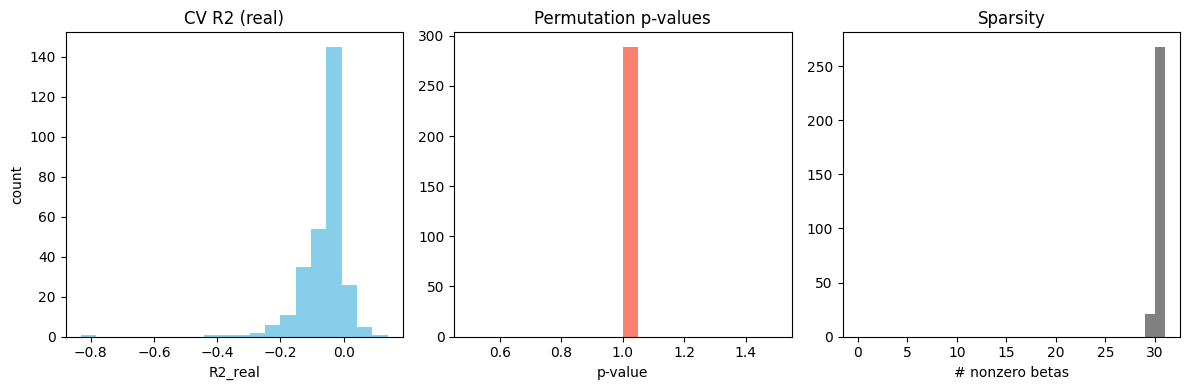

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("No results_df available. Run Section 5 first.")

print("R2 real: mean {:.3f}, median {:.3f}".format(results_df['r2_real'].mean(), results_df['r2_real'].median()))
print("p-value: mean {:.3f}, median {:.3f}".format(results_df['p_val'].mean(), results_df['p_val'].median()))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(results_df['r2_real'].dropna(), bins=20, color='skyblue')
plt.xlabel('R2_real')
plt.ylabel('count')
plt.title('CV R2 (real)')

plt.subplot(1,3,2)
plt.hist(results_df['p_val'].dropna(), bins=20, color='salmon')
plt.xlabel('p-value')
plt.title('Permutation p-values')

plt.subplot(1,3,3)
plt.hist(results_df['n_nonzero'], bins=range(0, len(predictor_labels)+2), color='gray')
plt.xlabel('# nonzero betas')
plt.title('Sparsity')
plt.tight_layout()
plt.show()


## 7. PCA on betas

Run PCA across units on the beta_df (intercept dropped).

PCA on 289 units, 30 predictors
Explained variance ratio (first 5): [0.1932617  0.11222922 0.08359153 0.07410078 0.0652442 ]


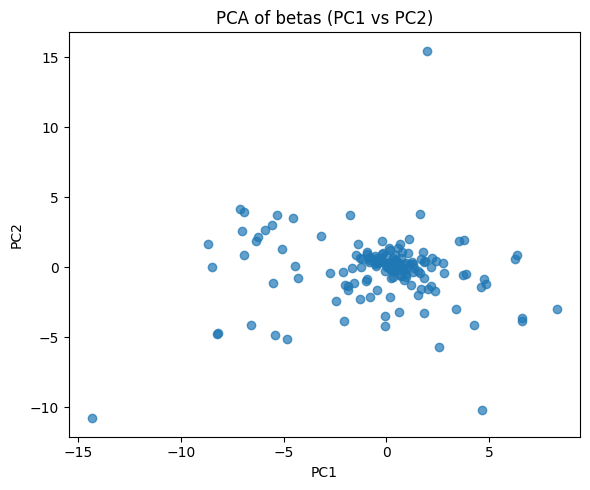

Top positive loadings PC1: load3_rank3=3    0.286905
load3_rank2=5    0.276611
load3_rank1=3    0.272236
load3_rank3=1    0.265280
load3_rank2=2    0.249823
dtype: float64
Top negative loadings PC1: load1_rank1=1   -0.275186
load1_rank1=2   -0.263270
load1_rank1=5   -0.236680
load1_rank1=4   -0.204855
load1_rank1=3   -0.086558
dtype: float64


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if 'beta_df' not in globals() or beta_df is None:
    raise ValueError("Run Section 5 to compute beta_df first.")

# Drop intercept and meta columns
meta_cols = ['intercept', 'subject_id', 'session_id', 'unit_id', 'filepath']
beta_only = beta_df.drop(columns=[c for c in meta_cols if c in beta_df.columns])

# Remove units with NaN betas
mask_complete = ~beta_only.isna().any(axis=1)
beta_clean = beta_only[mask_complete]
meta_clean = beta_df.loc[mask_complete, ['subject_id', 'session_id', 'unit_id']] if 'subject_id' in beta_df else None

# Standardize predictors across units
scaler = StandardScaler(with_mean=True, with_std=True)
beta_scaled = scaler.fit_transform(beta_clean)

n_components = min(5, beta_scaled.shape[1])
pca = PCA(n_components=n_components)
scores = pca.fit_transform(beta_scaled)
explained = pca.explained_variance_ratio_

print(f"PCA on {beta_scaled.shape[0]} units, {beta_scaled.shape[1]} predictors")
print("Explained variance ratio (first 5):", explained)

# Scatter of PC1 vs PC2
plt.figure(figsize=(6,5))
plt.scatter(scores[:,0], scores[:,1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of betas (PC1 vs PC2)')
plt.tight_layout()
plt.show()

# Top loading predictors for PC1
loadings = pd.Series(pca.components_[0], index=beta_clean.columns)
top_pos = loadings.sort_values(ascending=False).head(5)
top_neg = loadings.sort_values(ascending=True).head(5)
print("Top positive loadings PC1:", top_pos)
print("Top negative loadings PC1:", top_neg)


## 8. Plot PCs by condition (load × rank)

Projects condition betas (average over units) into PCA space.

/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does n

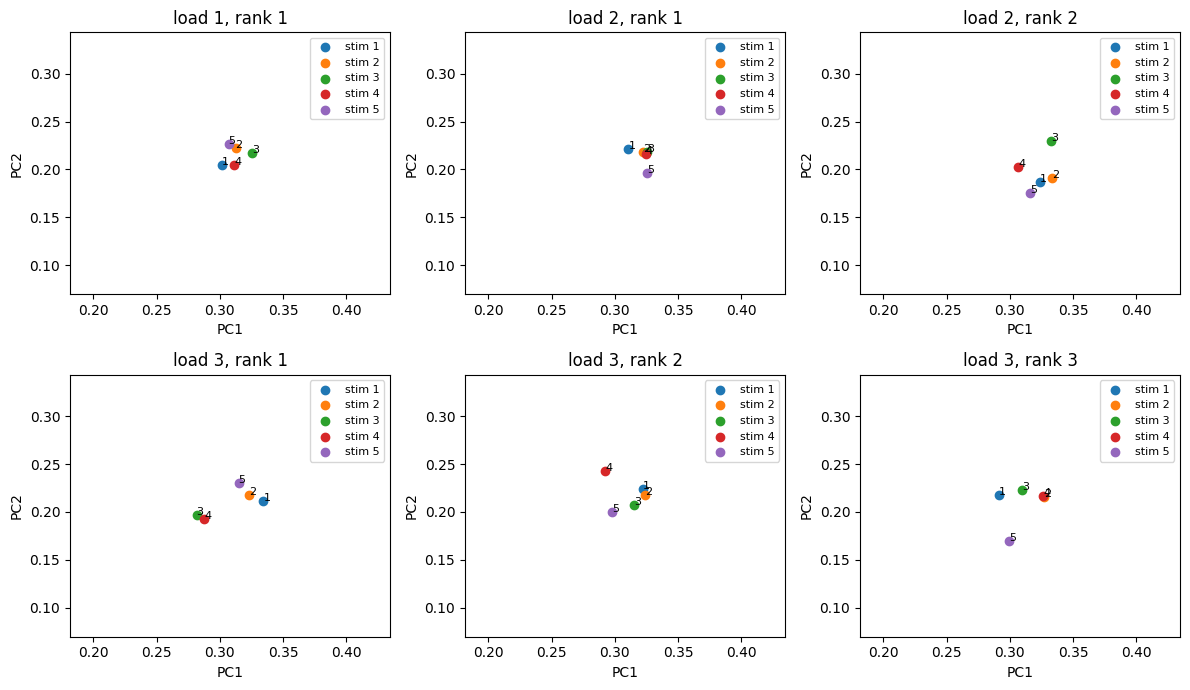

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import re

if 'beta_df' not in globals() or beta_df is None:
    raise ValueError("Run Section 5 to compute beta_df first.")

meta_cols = ['intercept', 'subject_id', 'session_id', 'unit_id', 'filepath']
beta_only = beta_df.drop(columns=[c for c in meta_cols if c in beta_df.columns])
mask_complete = ~beta_only.isna().any(axis=1)
beta_clean = beta_only[mask_complete]

# Standardize across units
scaler = StandardScaler(with_mean=True, with_std=True)
beta_scaled = scaler.fit_transform(beta_clean)

pca = PCA(n_components=3)
pca.fit(beta_scaled)

# Parse predictor labels into (load, rank, stim)
pred_info = []
pat = re.compile(r"load(\d+)_rank(\d+)=([\d]+)")
for lbl in beta_clean.columns:
    m = pat.match(lbl)
    if m:
        pred_info.append({'label': lbl, 'load': int(m.group(1)), 'rank': int(m.group(2)), 'stim': int(m.group(3))})
    else:
        pred_info.append({'label': lbl, 'load': None, 'rank': None, 'stim': None})
pred_info_df = pd.DataFrame(pred_info)

# Compute all coords to set common axis limits
coords_all = []
for load_val, rank_val in [(1,1), (2,1), (2,2), (3,1), (3,2), (3,3)]:
    sub_labels = pred_info_df[(pred_info_df['load']==load_val) & (pred_info_df['rank']==rank_val)]['label']
    for lbl in sub_labels:
        vec = np.zeros((1, beta_clean.shape[1]))
        if lbl in beta_clean.columns:
            idx = beta_clean.columns.get_loc(lbl)
            vec[0, idx] = beta_clean[lbl].mean()
        vec_scaled = scaler.transform(vec)
        coord = pca.transform(vec_scaled)[0][:2]
        coords_all.append(coord)
coords_all = np.array(coords_all)
xlim = (coords_all[:,0].min()-0.1, coords_all[:,0].max()+0.1)
ylim = (coords_all[:,1].min()-0.1, coords_all[:,1].max()+0.1)

# Project each stim within each load/rank group into PC space
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for ax_idx, (load_val, rank_val) in enumerate([(1,1), (2,1), (2,2), (3,1), (3,2), (3,3)]):
    ax = axes[ax_idx]
    sub_labels = pred_info_df[(pred_info_df['load']==load_val) & (pred_info_df['rank']==rank_val)]['label']
    if len(sub_labels) == 0:
        ax.set_title(f"load {load_val} rank {rank_val}(no predictors)")
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        continue
    for lbl in sub_labels:
        vec = np.zeros((1, beta_clean.shape[1]))
        if lbl in beta_clean.columns:
            idx = beta_clean.columns.get_loc(lbl)
            vec[0, idx] = beta_clean[lbl].mean()
        vec_scaled = scaler.transform(vec)
        coord = pca.transform(vec_scaled)[0][:2]
        stim_val = pred_info_df[pred_info_df['label']==lbl]['stim'].values[0]
        ax.scatter(coord[0], coord[1], label=f"stim {stim_val}")
        ax.text(coord[0], coord[1], f"{stim_val}", fontsize=8)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f"load {load_val}, rank {rank_val}")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Stim separation: pairwise distances per condition

For each load/rank condition, compute the average pairwise Euclidean distance between the 5 stimuli in PCA space.

In [25]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import re
from itertools import combinations

if 'beta_df' not in globals() or beta_df is None:
    raise ValueError("Run Section 5 to compute beta_df first.")

meta_cols = ['intercept', 'subject_id', 'session_id', 'unit_id', 'filepath']
beta_only = beta_df.drop(columns=[c for c in meta_cols if c in beta_df.columns])
mask_complete = ~beta_only.isna().any(axis=1)
beta_clean = beta_only[mask_complete]

# Standardize across units
scaler = StandardScaler(with_mean=True, with_std=True)
beta_scaled = scaler.fit_transform(beta_clean)

# PCA on full predictor space
pca = PCA(n_components=min(10, beta_scaled.shape[1]))
pca.fit(beta_scaled)

# Parse predictor labels into (load, rank, stim)
pred_info = []
pat = re.compile(r"load(\d+)_rank(\d+)=([\d]+)")
for lbl in beta_clean.columns:
    m = pat.match(lbl)
    if m:
        pred_info.append({'label': lbl, 'load': int(m.group(1)), 'rank': int(m.group(2)), 'stim': int(m.group(3))})
    else:
        pred_info.append({'label': lbl, 'load': None, 'rank': None, 'stim': None})
pred_info_df = pd.DataFrame(pred_info)

# Helper to project a single predictor into PC space
def project_label(lbl):
    vec = np.zeros((1, beta_clean.shape[1]))
    if lbl in beta_clean.columns:
        idx = beta_clean.columns.get_loc(lbl)
        vec[0, idx] = beta_clean[lbl].mean()
    vec_scaled = scaler.transform(vec)
    return pca.transform(vec_scaled)[0]

# Compute distances per condition
records = []
for load_val, rank_val in [(1,1), (2,1), (2,2), (3,1), (3,2), (3,3)]:
    sub_labels = pred_info_df[(pred_info_df['load']==load_val) & (pred_info_df['rank']==rank_val)]['label']
    if len(sub_labels) == 0:
        continue
    coords = [project_label(lbl) for lbl in sub_labels]
    coords = np.array(coords)
    dists = []
    for i,j in combinations(range(len(coords)), 2):
        d = np.linalg.norm(coords[i] - coords[j])
        dists.append(d)
    records.append({
        'load': load_val,
        'rank': rank_val,
        'avg_pairwise_dist': float(np.mean(dists)),
        'median_pairwise_dist': float(np.median(dists)),
        'min_pairwise_dist': float(np.min(dists)),
        'max_pairwise_dist': float(np.max(dists))
    })

sep_df = pd.DataFrame(records)
print("Pairwise distances per condition (using full PCA space):")
print(sep_df)


Pairwise distances per condition (using full PCA space):
   load  rank  avg_pairwise_dist  median_pairwise_dist  min_pairwise_dist  \
0     1     1           0.039786              0.038589           0.025287   
1     2     1           0.036016              0.039155           0.017480   
2     2     2           0.087919              0.090139           0.046424   
3     3     1           0.094539              0.086822           0.021857   
4     3     2           0.072988              0.066499           0.016770   
5     3     3           0.080413              0.061788           0.016210   

   max_pairwise_dist  
0           0.058398  
1           0.053792  
2           0.124327  
3           0.156012  
4           0.127303  
5           0.142702  


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does n

### Plot stimulus separation vs load/rank

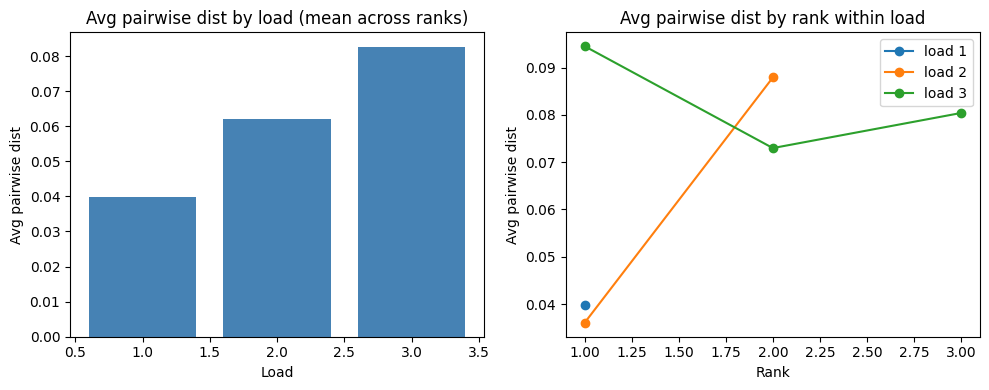

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

if 'sep_df' not in globals() or len(sep_df) == 0:
    raise ValueError("Run Section 9 to compute sep_df first.")

# Bar plots by load and rank
fig, axes = plt.subplots(1, 2, figsize=(10,4))
# By load (aggregate ranks)
sep_load = sep_df.groupby('load')['avg_pairwise_dist'].mean().reset_index()
axes[0].bar(sep_load['load'], sep_load['avg_pairwise_dist'], color='steelblue')
axes[0].set_xlabel('Load')
axes[0].set_ylabel('Avg pairwise dist')
axes[0].set_title('Avg pairwise dist by load (mean across ranks)')

# By rank within each load
for load_val in sorted(sep_df['load'].unique()):
    sub = sep_df[sep_df['load'] == load_val]
    axes[1].plot(sub['rank'], sub['avg_pairwise_dist'], marker='o', label=f"load {load_val}")
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Avg pairwise dist')
axes[1].set_title('Avg pairwise dist by rank within load')
axes[1].legend()
plt.tight_layout()
plt.show()
